# Análise Exploratória de Dados (EDA) - PETR4.SA

Este notebook documenta a análise exploratória da série temporal da Petrobras (PETR4.SA)

## Objetivos
- Compreender a distribuição histórica dos preços de fechamento.
- Analisar a volatilidade e os retornos diários do ativo.
- Levantar *insights* relevantes que justifiquem as decisões arquiteturais adotadas no modelo preditivo LSTM.

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Coleta de Dados
Extração do histórico dos últimos anos da PETR4 diretamente da API do Yahoo Finance para capturar as oscilações macroeconômicas.

In [2]:
ticker = "PETR4.SA"
df = yf.download(ticker, start="2020-01-01", end="2024-01-01", progress=False)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2020-01-02,8.816067,8.816067,8.704071,8.761505,37774500
2020-01-03,8.744275,8.971138,8.744275,8.867757,71595600
2020-01-06,8.847656,8.884988,8.600692,8.738533,81844000
2020-01-07,8.813195,8.867757,8.750018,8.850527,32822000
2020-01-08,8.758631,8.836166,8.683967,8.813193,48215600


## 2. Análise de Preço de Fechamento e Tendência
O preço de fechamento (`Close`) é o nosso *target* (variável alvo) para o modelo LSTM. Analisaremos seu comportamento em conjunto com médias móveis (MA) para filtrar a volatilidade diária.

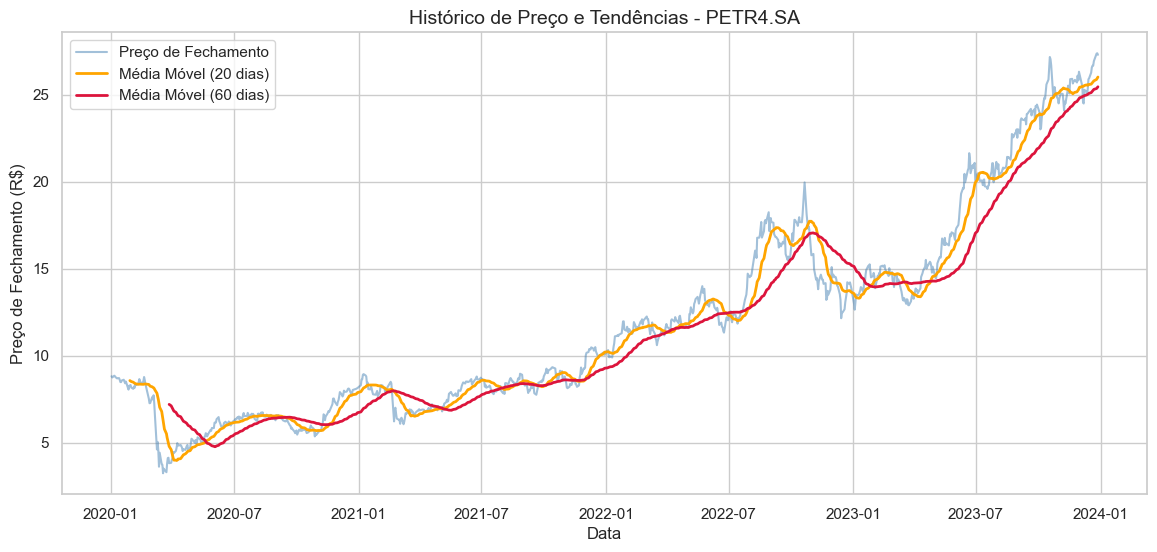

In [3]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()

plt.plot(df.index, df['Close'], label='Preço de Fechamento', color='steelblue', alpha=0.5)
plt.plot(df.index, df['MA20'], label='Média Móvel (20 dias)', color='orange', linewidth=2)
plt.plot(df.index, df['MA60'], label='Média Móvel (60 dias)', color='crimson', linewidth=2)

plt.title('Histórico de Preço e Tendências - PETR4.SA', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (R$)')
plt.legend()
plt.show()

## 3. Retornos Diários e Volatilidade
A série de retornos diários revela os "choques" do mercado. Observar a distribuição ajuda a identificar a probabilidade de eventos extremos (caudas longas).

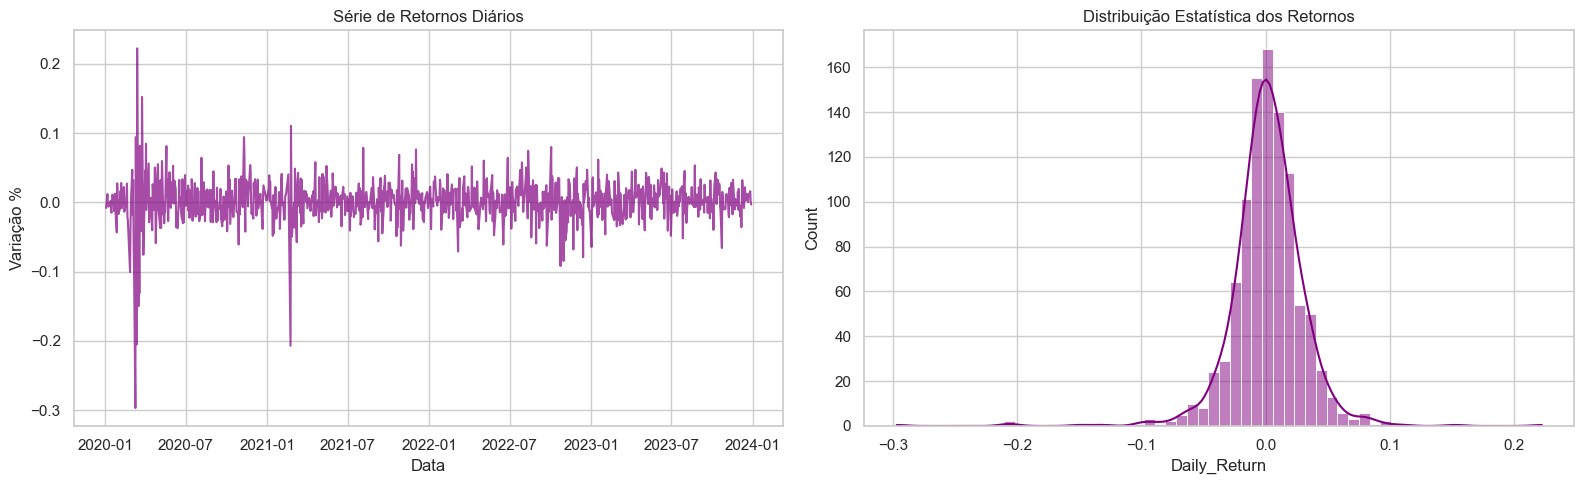

In [4]:
df['Daily_Return'] = df['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Linha (Volatilidade)
axes[0].plot(df.index, df['Daily_Return'], color='purple', alpha=0.7)
axes[0].set_title('Série de Retornos Diários')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Variação %')

# Histograma (Distribuição)
sns.histplot(df['Daily_Return'].dropna(), bins=60, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribuição Estatística dos Retornos')

plt.tight_layout()
plt.show()

## 4. Conclusões de Negócio e Insights para Modelagem (MLOps)

1. **Escolha da Arquitetura (LSTM):** A série de preços possui longos ciclos de tendência direcional intercalados com correções abruptas (não-estacionária). Modelos lineares clássicos não são ideais aqui. A adoção de Redes Neurais Recorrentes (LSTM) justifica-se pela sua capacidade nativa de reter a "memória" direcional do mercado de curto e longo prazo.
2. **Justificativa da Janela (60 dias):** No gráfico de tendências, nota-se que a Média Móvel de 60 dias (`MA60`) capta muito bem a inércia macroeconômica do ativo, filtrando ruídos. Isso baliza tecnicamente nossa decisão de utilizar `timesteps=60` na engenharia de features do nosso modelo (`src/models/train.py`).
3. **Alerta de Degradação (Concept Drift):** O gráfico de retornos demonstra a existência de regimes de baixa e altíssima volatilidade. Em ambientes produtivos, treinar um modelo em um regime de baixa volatilidade e inferir durante uma crise resulta em falha catastrófica. Isso reforça a necessidade arquitetural da nossa pipeline MLOps incluir a biblioteca **Evidently** para monitoramento contínuo da estabilidade populacional (PSI), garantindo retreinamentos automatizados via **Airflow**.